In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv(
    "../data/Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)

df[["Order Date", "Sales"]].head()

,Order Date,Sales
0,2016-11-08,261.9600
1,2016-11-08,731.9400
2,2016-06-12,14.6200
3,2015-10-11,957.5775
4,2015-10-11,22.3680


In [7]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
df = df.dropna(subset=["Order Date", "Sales"])

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (9994, 21)


In [9]:
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

daily_sales.columns = ["Date", "Sales"]

daily_sales.head()

,Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [10]:
print(daily_sales.shape)

daily_sales.info()

(1237, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1237 entries, 0 to 1236
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1237 non-null   datetime64[ns]
 1   Sales   1237 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.5 KB


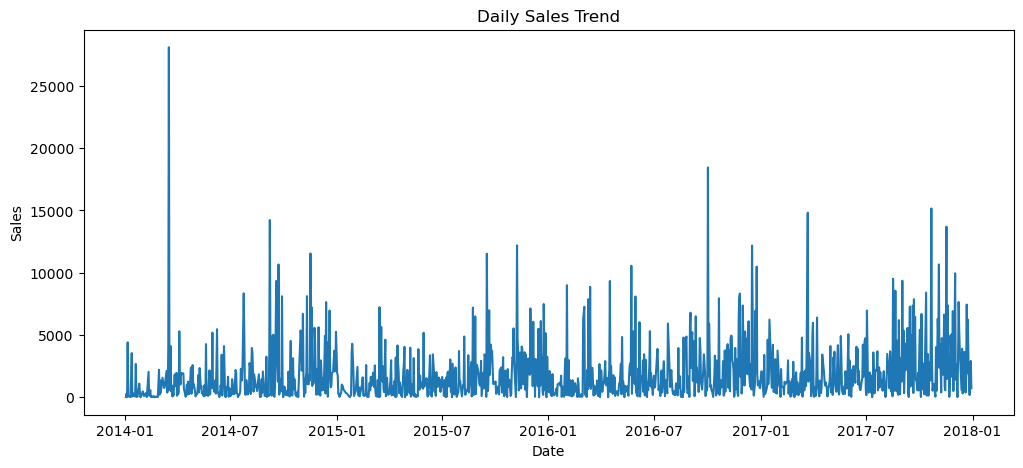

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(daily_sales["Date"], daily_sales["Sales"])

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.savefig("../images/daily_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()

In [12]:
daily_sales["Year"] = daily_sales["Date"].dt.year
daily_sales["Month"] = daily_sales["Date"].dt.month
daily_sales["Day"] = daily_sales["Date"].dt.day
daily_sales["DayOfWeek"] = daily_sales["Date"].dt.dayofweek

daily_sales.head()

,Date,Sales,Year,Month,Day,DayOfWeek
0,2014-01-03,16.448,2014,1,3,4
1,2014-01-04,288.060,2014,1,4,5
2,2014-01-05,19.536,2014,1,5,6
3,2014-01-06,4407.100,2014,1,6,0
4,2014-01-07,87.158,2014,1,7,1


In [13]:
daily_sales["DayNumber"] = np.arange(len(daily_sales))

daily_sales.head()

,Date,Sales,Year,Month,Day,DayOfWeek,DayNumber
0,2014-01-03,16.448,2014,1,3,4,0
1,2014-01-04,288.060,2014,1,4,5,1
2,2014-01-05,19.536,2014,1,5,6,2
3,2014-01-06,4407.100,2014,1,6,0,3
4,2014-01-07,87.158,2014,1,7,1,4


In [14]:
features = [
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "DayNumber"
]

X = daily_sales[features]
y = daily_sales["Sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Year  Month  Day  DayOfWeek  DayNumber
0  2014      1    3          4          0
1  2014      1    4          5          1
2  2014      1    5          6          2
3  2014      1    6          0          3
4  2014      1    7          1          4

Target:
0      16.448
1     288.060
2      19.536
3    4407.100
4      87.158
Name: Sales, dtype: float64


In [15]:
split_index = int(len(daily_sales) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (989, 5)
Testing data: (248, 5)


In [16]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [17]:
predictions = model.predict(X_test)

print(predictions[:5])

[1394.158305 1935.565646 2168.436417 2268.255798 2056.999548]


In [18]:
results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": predictions
})

results.head()

,Actual Sales,Predicted Sales
0,808.4700,1394.158305
1,114.4200,1935.565646
2,1971.2905,2168.436417
3,6401.9300,2268.255798
4,1626.7100,2056.999548


In [19]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(y_test, predictions)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 2))

MAE: 1739.39
RMSE: 2340.7
R² Score: 0.1


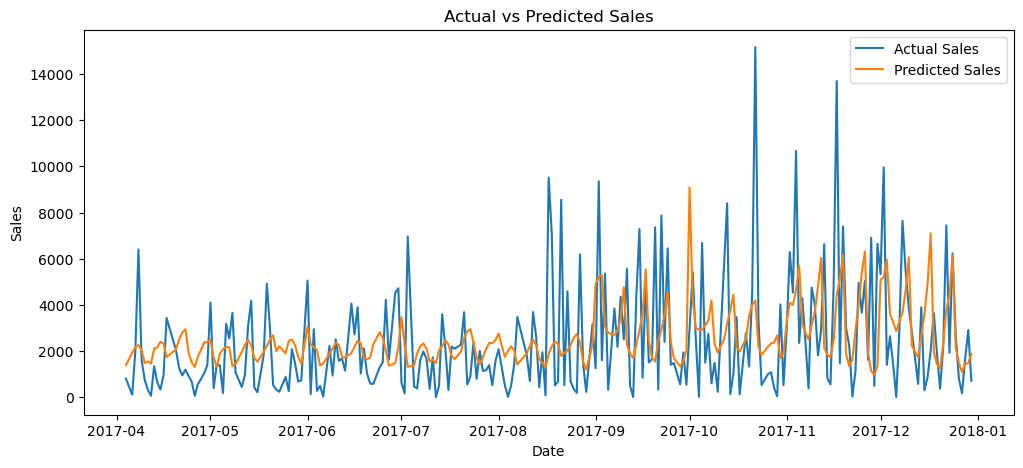

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales["Date"].iloc[split_index:],
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    daily_sales["Date"].iloc[split_index:],
    predictions,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.savefig("../images/actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

In [21]:
last_date = daily_sales["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30
)

future_df = pd.DataFrame({
    "Date": future_dates
})

future_df.head()

,Date
0,2017-12-31
1,2018-01-01
2,2018-01-02
3,2018-01-03
4,2018-01-04


In [23]:
future_df["Year"] = future_df["Date"].dt.year
future_df["Month"] = future_df["Date"].dt.month
future_df["Day"] = future_df["Date"].dt.day
future_df["DayOfWeek"] = future_df["Date"].dt.dayofweek

last_day_number = daily_sales["DayNumber"].max()

future_df["DayNumber"] = np.arange(
    last_day_number + 1,
    last_day_number + 31
)

future_df.head()

,Date,Year,Month,Day,DayOfWeek,DayNumber
0,2017-12-31,2017,12,31,6,1237
1,2018-01-01,2018,1,1,0,1238
2,2018-01-02,2018,1,2,1,1239
3,2018-01-03,2018,1,3,2,1240
4,2018-01-04,2018,1,4,3,1241


In [24]:
future_X = future_df[features]

future_df["Predicted Sales"] = model.predict(future_X)

future_df[["Date", "Predicted Sales"]].head()

,Date,Predicted Sales
0,2017-12-31,3615.350156
1,2018-01-01,2535.843342
2,2018-01-02,1969.127221
3,2018-01-03,1414.720581
4,2018-01-04,1591.610817


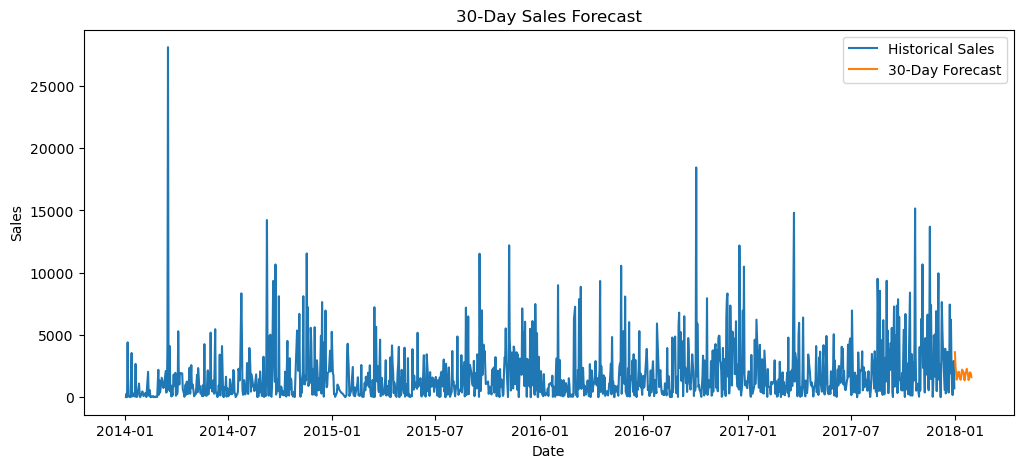

In [28]:
plt.figure(figsize=(12, 5))

# Historical sales
plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"],
    label="Historical Sales"
)

# Future predicted sales
plt.plot(
    future_df["Date"],
    future_df["Predicted Sales"],
    label="30-Day Forecast"
)

plt.title("30-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.savefig("../images/30_day_forecast.png", dpi=300, bbox_inches="tight")

plt.show()

# Business Insights

## Sales Forecast Summary

The Machine Learning model analyzes historical sales data and predicts sales for the next 30 days.

## How Businesses Can Use This Forecast

- Plan inventory based on expected demand.
- Avoid overstocking and reduce unnecessary costs.
- Prepare for periods of higher sales.
- Improve staffing and resource planning.
- Support budgeting and cash flow decisions.

## Conclusion

This sales forecasting system demonstrates how Machine Learning can help businesses make data-driven decisions. By analyzing historical sales patterns, the model provides future sales predictions that can support inventory management, financial planning, and business growth.